# Évaluation NL — scénario `enact_scenario`

Analyse des 34 intentions NL générées à la main (14 `extended` + 20 `clarity_spectrum`),
chacune rejouée 3× à travers le **vrai** pipeline (`intent_grounding_node` → LLM réel via
OpenRouter → `necessity_checker_node` → `decision_engine_node`).

Ce notebook ne fait **aucun appel LLM** : il lit uniquement le résultat déjà scoré
(`experimentation/data/nl_evaluation_scored.csv`, produit par
`experimentation/scripts/run_nl_evaluation.py` puis `score_nl_evaluation.py`). On peut donc
relancer les cellules autant de fois qu'on veut sans coût ni risque.

Deux couches sont analysées séparément, volontairement jamais fusionnées dans un seul score :
- **Extraction** : le LLM a-t-il correctement transformé l'intention en `Requirement` structuré ?
- **Décision** : une fois l'extraction faite, `necessity_checker`/`decision_engine` ont-ils pris
  la bonne décision ? (dépend de bugs du moteur déjà documentés dans `RESULTS.md`, indépendants
  de la qualité de l'extraction)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)

df = pd.read_csv("../data/nl_evaluation_scored.csv")
print(f"{len(df)} lignes ({df['id'].nunique()} cas x jusqu'à 3 runs)")
df.head()

102 lignes (34 cas x jusqu'à 3 runs)


,id,dataset_source,clarity_tier,run,expected_service,expected_kpi_type,n_expected,n_extracted,n_true_positive,n_false_positive,n_false_negative,service_correct,kpi_type_correct,comparator_correct,value_correct,unit_correct,exact_match,error_category,necessity_status,decision_kind,elapsed_s
0,enact-101,extended,NaN,1,F1,cpu,1,1,1,0,0,True,True,True,True,True,True,ok,no_action_needed,no_change,1.78
1,enact-101,extended,NaN,2,F1,cpu,1,1,1,0,0,True,True,True,True,True,True,ok,no_action_needed,no_change,1.23
2,enact-101,extended,NaN,3,F1,cpu,1,1,1,0,0,True,True,True,True,True,True,ok,no_action_needed,no_change,1.12
3,enact-102,extended,NaN,1,F1,cpu,1,1,1,0,0,True,True,True,True,True,True,ok,reconfiguration_required,no_valid_placement,2.17
4,enact-102,extended,NaN,2,F1,cpu,1,1,1,0,0,True,True,True,True,True,True,ok,reconfiguration_required,no_valid_placement,2.13


## 1. Vue d'ensemble — extraction

`exact_match` = l'extraction reproduit exactement la vérité terrain (même service, même KPI,
même comparateur, même valeur à 5% près, même unité — et rien en trop). C'est un score binaire
strict par (cas, run). Precision/Recall/F1 sont calculés à partir des compteurs
`n_true_positive`/`n_false_positive`/`n_false_negative` (comptage au niveau "requirement", pas
juste "cas") — plus robustes qu'un binaire quand un cas a une sur- ou sous-extraction partielle.

In [2]:
def prf1(group: pd.DataFrame) -> pd.Series:
    """Precision/recall/F1 from summed TP/FP/FN over a group of rows, plus the
    simpler exact-match rate and a row count for context (small-N caveat)."""
    tp, fp, fn = group["n_true_positive"].sum(), group["n_false_positive"].sum(), group["n_false_negative"].sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    f1 = 2 * precision * recall / (precision + recall) if precision and recall else np.nan
    return pd.Series({
        "n": len(group),
        "exact_match_rate": group["exact_match"].mean(),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    })

overview = prf1(df)
overview.to_frame("valeur").round(3)

,valeur
n,102.000
exact_match_rate,0.853
precision,0.941
recall,0.889
f1,0.914


## 2. Par source de données (`extended` vs `clarity_spectrum`)

Les 14 cas `extended` n'avaient jamais été testés avec le vrai LLM avant aujourd'hui (ils
avaient été validés en contournant le LLM, vérité terrain injectée directement — voir
`RESULTS.md` Partie 2). C'est la première mesure réelle de leur taux d'extraction.

In [3]:
by_source = df.groupby("dataset_source").apply(prf1, include_groups=False).round(3)
by_source

,n,exact_match_rate,precision,recall,f1
dataset_source,,,,,
clarity_spectrum,60.0,0.883,0.936,0.917,0.926
extended,42.0,0.810,0.947,0.857,0.900


## 3. Par type de KPI

Les cas d'abstention (aucun `expected_kpi_type`, palier 5) sont exclus ici — pas de KPI à
mesurer pour eux, ils sont couverts séparément en §5 (taxonomie) sous `hallucination_sur_vague`
vs `ok`. Attention : certains KPI n'ont que 6-9 lignes (2-3 cas × 3 runs) — lire les proportions
avec cette taille d'échantillon en tête, ce n'est pas un benchmark à ce stade.

In [4]:
has_kpi = df[df["expected_kpi_type"] != ""]
by_kpi = has_kpi.groupby("expected_kpi_type").apply(prf1, include_groups=False).round(3)
by_kpi.sort_values("n", ascending=False)

,n,exact_match_rate,precision,recall,f1
expected_kpi_type,,,,,
cpu,30.0,1.000,1.000,1.000,1.000
energy,24.0,0.833,0.885,0.958,0.920
storage,12.0,0.833,1.000,0.833,0.909
latency,9.0,0.111,0.600,0.333,0.429
network_in,6.0,1.000,1.000,1.000,1.000
network_out,6.0,0.833,1.000,0.833,0.909
ram,3.0,1.000,1.000,1.000,1.000


## 4. Par palier de clarté (`clarity_spectrum` uniquement — 1 explicite → 5 vague)

In [5]:
has_tier = df[df["clarity_tier"].notna()].copy()
has_tier["clarity_tier"] = has_tier["clarity_tier"].astype(int)
by_tier = has_tier.groupby("clarity_tier").apply(prf1, include_groups=False).round(3)
by_tier

,n,exact_match_rate,precision,recall,f1
clarity_tier,,,,,
1,12.0,1.000,1.00,1.000,1.000
2,12.0,0.917,1.00,0.917,0.957
3,12.0,1.000,1.00,1.000,1.000
4,12.0,0.500,0.75,0.750,0.750
5,12.0,1.000,NaN,NaN,NaN


## 5. Taxonomie d'erreurs

Catégorie unique par (cas, run), attribuée par ordre de priorité dans `score_nl_evaluation.py`
(sous-extraction > sur-extraction > confusion de service > confusion de KPI > comparateur >
unité > valeur > ok). `hallucination_sur_vague` = le LLM a inventé un seuil sur un cas du
palier 5 où la vérité terrain est une liste vide — le signal le plus important à surveiller
(risque de décision prise sur une intention mal comprise).

In [6]:
error_counts = df["error_category"].value_counts()
error_counts_by_case = (
    df[df["error_category"] != "ok"]
    .groupby(["error_category", "id"])
    .size()
    .reset_index(name="occurrences")
    .sort_values(["error_category", "occurrences"], ascending=[True, False])
)
print(error_counts)
print()
error_counts_by_case

error_category
ok                   87
confusion_service     7
sur_extraction        5
sous_extraction       3
Name: count, dtype: int64



,error_category,id,occurrences
0,confusion_service,enact-109,3
1,confusion_service,enact-110,3
2,confusion_service,enact-215,1
4,sous_extraction,enact-216,2
3,sous_extraction,enact-206,1
6,sur_extraction,enact-213,3
5,sur_extraction,enact-111,2


## 6. Stabilité inter-run

Combien des 3 runs sont un `exact_match`, par cas. Un cas à 3/3 est fiable ; un cas à 1/3 ou 2/3
indique une vraie instabilité (pas juste un run malchanceux) — à surveiller en particulier vu
que `llm_openrouter.py` route chaque requête vers un provider différent (pas de garantie de
déterminisme strict même à `temperature=0`, voir le docstring du fichier).

In [7]:
stability = df.groupby(["id", "dataset_source", "clarity_tier"])["exact_match"].sum().reset_index()
stability = stability.rename(columns={"exact_match": "runs_corrects_sur_3"})
stability_dist = stability["runs_corrects_sur_3"].value_counts().sort_index()
print("Distribution (nombre de cas par score de stabilité) :")
print(stability_dist)
print()
print("Cas instables (< 3/3) :")
stability[stability["runs_corrects_sur_3"] < 3].sort_values("runs_corrects_sur_3")

Distribution (nombre de cas par score de stabilité) :
runs_corrects_sur_3
0     1
1     1
2     2
3    16
Name: count, dtype: int64

Cas instables (< 3/3) :


,id,dataset_source,clarity_tier,runs_corrects_sur_3
12,enact-213,clarity_spectrum,4.0,0
15,enact-216,clarity_spectrum,4.0,1
5,enact-206,clarity_spectrum,2.0,2
14,enact-215,clarity_spectrum,4.0,2


## 7. Graphe — taux d'extraction correcte par palier de clarté

Version visuelle du tableau §4. Sauvegardé en PNG dans `experimentation/figures/`.

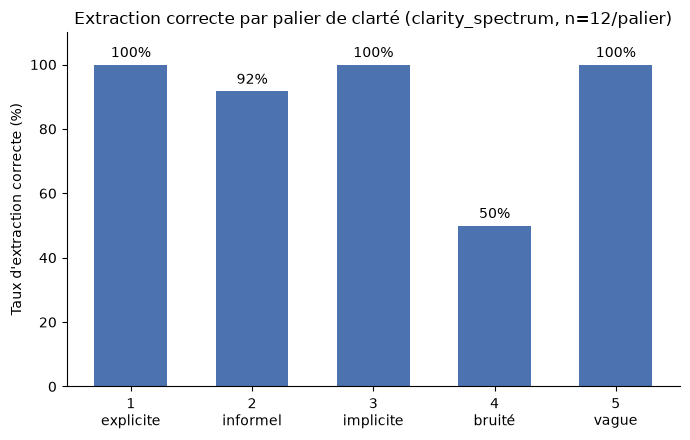

In [8]:
tier_labels = {1: "1\nexplicite", 2: "2\ninformel", 3: "3\nimplicite", 4: "4\nbruité", 5: "5\nvague"}

fig, ax = plt.subplots(figsize=(7, 4.5))
rates = by_tier["exact_match_rate"] * 100
bars = ax.bar([tier_labels[t] for t in rates.index], rates.values, color="#4C72B0", width=0.6)
ax.bar_label(bars, fmt="%.0f%%", padding=3)
ax.set_ylim(0, 110)
ax.set_ylabel("Taux d'extraction correcte (%)")
ax.set_title("Extraction correcte par palier de clarté (clarity_spectrum, n=12/palier)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "accuracy_by_clarity_tier.png", dpi=150)
plt.show()

## 8. Graphe — répartition des types d'erreur par palier de clarté

Barres empilées : montre non seulement *combien* d'erreurs par palier, mais *quel type*.

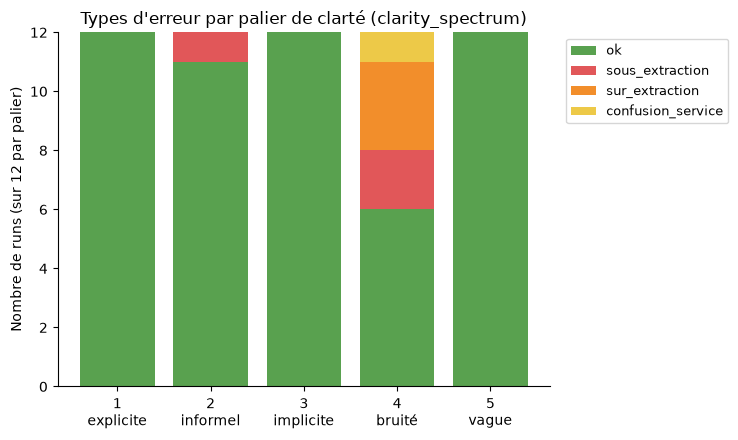

In [9]:
categories = ["ok", "sous_extraction", "sur_extraction", "confusion_service",
              "confusion_kpi", "comparateur_inverse", "unite_incorrecte",
              "valeur_incorrecte", "hallucination_sur_vague"]
colors = {"ok": "#59A14F", "sous_extraction": "#E15759", "sur_extraction": "#F28E2B",
          "confusion_service": "#EDC948", "confusion_kpi": "#B07AA1",
          "comparateur_inverse": "#FF9DA7", "unite_incorrecte": "#9C755F",
          "valeur_incorrecte": "#BAB0AC", "hallucination_sur_vague": "#76B7B2"}

pivot = has_tier.pivot_table(index="clarity_tier", columns="error_category", values="id",
                              aggfunc="count", fill_value=0)
pivot = pivot.reindex(columns=[c for c in categories if c in pivot.columns], fill_value=0)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
bottom = np.zeros(len(pivot))
for cat in pivot.columns:
    ax.bar([tier_labels[t] for t in pivot.index], pivot[cat], bottom=bottom,
           label=cat, color=colors.get(cat, "#CCCCCC"))
    bottom += pivot[cat].values
ax.set_ylabel("Nombre de runs (sur 12 par palier)")
ax.set_title("Types d'erreur par palier de clarté (clarity_spectrum)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "error_types_by_tier.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Croisement extraction × décision

**Attention, ceci n'est pas un score de décision** : on n'a pas encore de "décision attendue"
étiquetée pour chacun des 34 cas (seuls les 3 cas d'offload de la Partie 2 de `RESULTS.md` en
ont une explicite). C'est donc une table **descriptive** — qu'observe-t-on en aval, selon que
l'extraction était exacte ou non — pas encore une mesure de justesse de la décision. Un vrai
score de décision nécessiterait d'ajouter un champ `expected_necessity_status`/
`expected_decision` à la vérité terrain, pas encore fait ici.

In [10]:
crosstab = pd.crosstab(df["exact_match"], df["decision_kind"], margins=True, margins_name="total")
crosstab.index = crosstab.index.map({True: "extraction exacte", False: "extraction inexacte", "total": "total"})
crosstab

decision_kind,no_change,no_valid_placement,relocated,total
exact_match,,,,
extraction inexacte,12,0,3,15
extraction exacte,69,9,9,87
total,81,9,12,102


## 10. Couche décision seule (LLM contourné, vérité terrain injectée)

Symétrique de la Partie 2/4 de `RESULTS.md`, mais formalisé en script réutilisable
(`experimentation/scripts/run_decision_evaluation.py` → `score_decision_evaluation.py`) plutôt
qu'un test ad hoc. **Déterministe** (pas de LLM) — chaque cas tourne une seule fois, pas 3.

Périmètre : les 24 cas qui portent une intention de violation/satisfaction conçue à la main
(10 `intent_grounding_enact.jsonl` + 14 `extended`) — `clarity_spectrum` en est exclu, ces 20
cas n'ont jamais été conçus avec un statut attendu (violé/satisfait), donc rien d'honnête à
scorer à ce niveau pour eux.

`expected_necessity_status` est dérivé du tag `"violated"` déjà présent dans les fichiers
sources (aucun fichier modifié) : `reconfiguration_required` si présent, `no_action_needed`
sinon.

In [11]:
decision_df = pd.read_csv("../data/decision_evaluation_scored.csv")
n, n_correct = len(decision_df), decision_df["status_correct"].sum()
print(f"necessity_status correct : {n_correct}/{n} ({100 * n_correct / n:.0f}%)")
print()
print(decision_df["error_category"].value_counts())
print()
print("Détail des écarts :")
decision_df[~decision_df["status_correct"]][
    ["id", "dataset_source", "kpi_type", "service", "expected_necessity_status",
     "necessity_status", "error_category", "decision_kind"]
]

necessity_status correct : 17/24 (71%)

error_category
correct                    17
capacite_brute_vs_cible     6
kpi_non_gere                1
Name: count, dtype: int64

Détail des écarts :


,id,dataset_source,kpi_type,service,expected_necessity_status,necessity_status,error_category,decision_kind
0,enact-001,original,ram,C1,no_action_needed,reconfiguration_required,capacite_brute_vs_cible,relocated
2,enact-003,original,ram,C2,no_action_needed,reconfiguration_required,capacite_brute_vs_cible,relocated
4,enact-005,original,ram,F1,no_action_needed,reconfiguration_required,capacite_brute_vs_cible,no_valid_placement
6,enact-007,original,ram,F2,no_action_needed,reconfiguration_required,capacite_brute_vs_cible,no_valid_placement
8,enact-009,original,ram,P1,no_action_needed,reconfiguration_required,capacite_brute_vs_cible,no_valid_placement
11,enact-102,extended,cpu,F1,no_action_needed,reconfiguration_required,capacite_brute_vs_cible,no_valid_placement
17,enact-108,extended,energy,P1,reconfiguration_required,no_action_needed,kpi_non_gere,no_change


## 11. Conséquence réelle : quand le bug fait bouger de vrais services

Les cas en `capacite_brute_vs_cible` (RAM en MB comparée au `ram_gb` brut du nœud) ne se
contentent pas de mal classifier — sur `enact-001`/`enact-003`, `decision_engine` va jusqu'à
**relocaliser réellement des services** à cause du faux positif : `C1 → cloud-vm2`
(`enact-001`), et même `C2 → cloud-vm2` **et** `F1 → fog-node1` en cascade sur `enact-003` (la
contrainte de connectivité du DAG entier oblige à déplacer un second service pour garder le
premier valide). Sur les autres cas de cette catégorie, le seuil (en MB, traité comme des GB)
est si grand qu'aucun nœud n'y répond du tout → `NO_VALID_PLACEMENT`, une panne plus visible
mais tout aussi fausse.

## 12. Taux de rejet correct (abstention)

Isolé du tableau §4 : sur tout le dataset, seul le palier 5 de `clarity_spectrum`
(`enact-217`→`220`) a une vérité terrain vide (`expected_requirements: []`) — aucun seuil
numérique dans le texte, la bonne réponse est donc de ne rien extraire. C'est l'équivalent d'un
taux de "vrais négatifs" : parmi les cas où il n'y avait réellement rien à extraire, combien de
fois le LLM s'est correctement abstenu plutôt que d'halluciner un seuil.

**Limite à garder en tête** : seulement 4 cas (12 lignes), tous conçus avec le même type
d'ambiguïté (absence totale de chiffre) — aucun cas ne teste par exemple un chiffre présent mais
sans rapport avec une ressource du schéma, ou un chiffre sans unité claire. Un 100% ici ne
généralise pas au-delà de ce type précis d'ambiguïté.

In [12]:
abstain = df[df["n_expected"] == 0].copy()
abstain["rejet_correct"] = abstain["n_extracted"] == 0

n, n_ok = len(abstain), abstain["rejet_correct"].sum()
print(f"Taux de rejet correct : {n_ok}/{n} ({100 * n_ok / n:.0f}%)")
print()

per_case = (
    abstain.groupby("id")["rejet_correct"]
    .agg(runs_corrects="sum", total="count")
    .assign(taux=lambda d: (d["runs_corrects"] / d["total"] * 100).round(0))
)
per_case

Taux de rejet correct : 12/12 (100%)



,runs_corrects,total,taux
id,,,
enact-217,3,3,100.0
enact-218,3,3,100.0
enact-219,3,3,100.0
enact-220,3,3,100.0
